<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [18]:
# Check for GPU
!nvidia-smi

Mon Aug  3 16:10:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   61C    P8             17W /  111W |    2228MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
device

1.12.1


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [20]:
from torchvision.datasets import MNIST
from torchvision import transforms

MNIST_train = MNIST(root="data",
                     train=True,
                     download=True,
                     transform=transforms.ToTensor())

MNIST_test = MNIST(root="data",
                    train=False,
                    download=True,
                    transform=transforms.ToTensor())

## 6. Visualize at least 5 different samples of the MNIST training dataset.

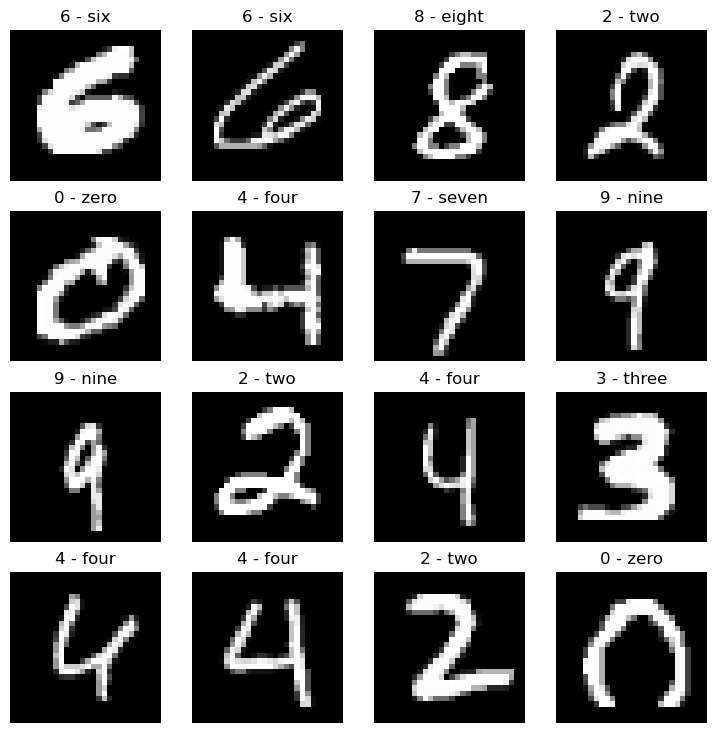

In [21]:
import matplotlib.pyplot as plt

class_names = MNIST_train.classes

# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(MNIST_train), size = [1]).item()
    img, label = MNIST_train[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [136]:
from torch.utils.data import DataLoader

train_data = DataLoader(MNIST_train,
                        batch_size=32,
                        shuffle=True)

test_data = DataLoader(MNIST_test,
                       batch_size=32,
                       shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [106]:
from torch import nn

class MNIST_MODEL(nn.Module):
    def __init__(self, input_shape: int, hidden_shape: int, output_shape: int):
        super().__init__()
        self.layer_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_shape,
                      kernel_size=3,
                      stride=1,
                      padding=0),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_shape,
                      out_channels=hidden_shape,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                          stride=2),
        )
        self.layer_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_shape,
                      out_channels=hidden_shape,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_shape,
                      out_channels=hidden_shape,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                          stride=2),
        )
        self.output_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_shape * 6 * 6,
                      out_features=output_shape)
        )
    def forward(self, x):
        x = self.layer_block_1(x)
        x = self.layer_block_2(x)
        x = self.output_layer(x)
        return x


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [107]:
model_on_cpu = MNIST_MODEL(input_shape=1,
                     hidden_shape=10,
                     output_shape=10)

model_on_gpu = MNIST_MODEL(input_shape=1,
                     hidden_shape=10,
                     output_shape=10)
model_on_gpu.to(device="cuda")

MNIST_MODEL(
  (layer_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (output_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=360, out_features=10, bias=True)
  )
)

In [108]:
import tqdm
from helper_functions import accuracy_fn

def train_loop(model:nn.Module, 
               data_loader:DataLoader, 
               loss_fn:nn.Module, 
               optimizer:torch.optim.Optimizer, 
               accuracy_fn,
               device:torch.device=device):
    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(data_loader):

        # Move data to device
        X, y = X.to(device), y.to(device)

        # Forward pass
        y_logits = model(X)
        y_pred = torch.argmax(y_logits, dim=1)

        # Calculate loss
        loss = loss_fn(y_logits, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred)
        train_loss += loss
        train_acc += acc

        # Optimizer zero grad
        optimizer.zero_grad()

        # Backward pass
        loss.backward()

        # Optimizer step
        optimizer.step()

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")


In [109]:
def test_loop(model:nn.Module, 
              data_loader:DataLoader, 
              loss_fn:nn.Module, 
              accuracy_fn,
              device:torch.device=device):
    model.eval()
    with torch.inference_mode():
        test_loss = 0
        test_acc = 0
        for batch, (X, y) in enumerate(data_loader):
            # Move data to device
            X, y = X.to(device), y.to(device)

            # Forward pass
            y_logits = model(X)
            y_pred = torch.argmax(y_logits, dim=1)

            # Calculate loss
            loss = loss_fn(y_logits, y)
            acc = accuracy_fn(y_true=y, y_pred=y_pred)
            test_loss += loss
            test_acc += acc

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}") 


In [110]:
loss_fn = nn.CrossEntropyLoss()
optimizer_cpu = torch.optim.SGD(params=model_on_cpu.parameters(),
                              lr=0.1)
optimizer_gpu = torch.optim.SGD(params=model_on_gpu.parameters(),
                              lr=0.1)


In [111]:
from timeit import default_timer as timer
from tqdm.auto import tqdm

epochs = 5

train_on_CPU_start = timer()
# CPU Training
for epoch in tqdm(range(epochs)):
    # Training
    train_loop(model=model_on_cpu,
               data_loader=train_data,
               loss_fn=loss_fn,
               optimizer=optimizer_cpu,
               accuracy_fn=accuracy_fn,
               device="cpu")

    # Testing
    test_loop(model=model_on_cpu,
              data_loader=test_data,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device="cpu")

train_on_CPU_end = timer()
print(f"CPU Training Time: {train_on_CPU_end - train_on_CPU_start:.4f} seconds")

train_on_GPU_start = timer()
# GPU Training
for epoch in tqdm(range(epochs)):
    # Training
    train_loop(model=model_on_gpu,
               data_loader=train_data,
               loss_fn=loss_fn,
               optimizer=optimizer_gpu,
               accuracy_fn=accuracy_fn,
               device="cuda")

    # Testing
    test_loop(model=model_on_gpu,
              data_loader=test_data,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device="cuda")
train_on_GPU_end = timer()
print(f"GPU Training Time: {train_on_GPU_end - train_on_GPU_start:.4f} seconds")


  0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.3916 | Train Acc: 86.4683


 20%|██        | 1/5 [00:22<01:31, 22.79s/it]

Test Loss: 0.0788 | Test Acc: 97.4541
Train Loss: 0.0795 | Train Acc: 97.5133


 40%|████      | 2/5 [00:45<01:07, 22.60s/it]

...

Test Loss: 0.0461 | Test Acc: 98.4225
Train Loss: 0.0482 | Train Acc: 98.5167


 80%|████████  | 4/5 [00:42<00:09,  9.37s/it]

Test Loss: 0.0426 | Test Acc: 98.7021
Train Loss: 0.0422 | Train Acc: 98.7017


100%|██████████| 5/5 [00:50<00:00, 10.13s/it]

Test Loss: 0.0379 | Test Acc: 98.7320
GPU Training Time: 50.6610 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

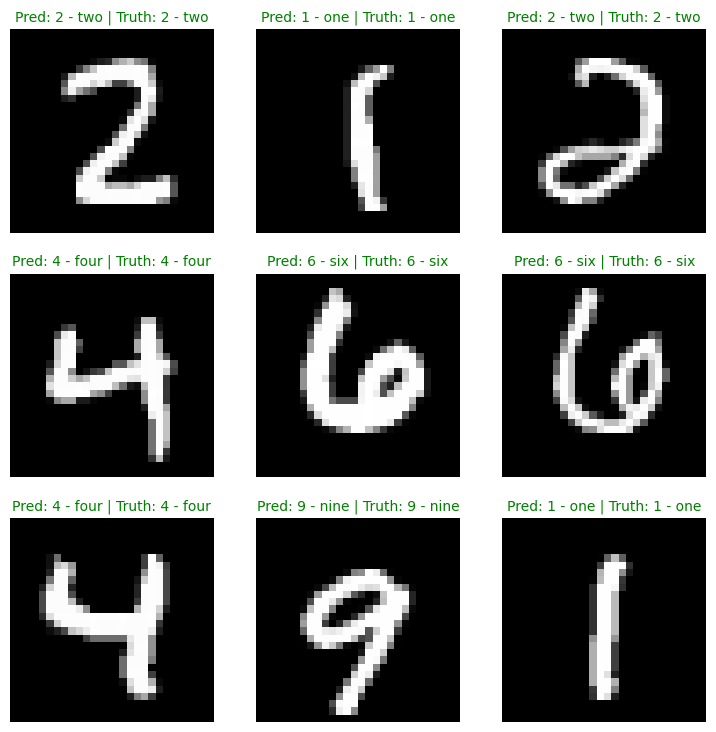

In [123]:
import random
random.seed(42)
test_samples = []
test_labels = []
pred_classes = []
for sample, label in random.sample(list(MNIST_test), k = 9):
    test_samples.append(sample)
    test_labels.append(label)

model_on_gpu.eval()

with torch.inference_mode():
    for i, sample in enumerate(test_samples):
        sample = sample.to(device)
        y_pred = model_on_gpu(sample.unsqueeze(0))
        pred_classes.append(y_pred.argmax(dim=1))

plt.figure(figsize=(9, 9))

nrows = 3
ncols = 3

for i, sample in enumerate(test_samples):
    # Create subplot
    plt.subplot(nrows, ncols, i+1)

    # Plot the target image
    plt.imshow(sample.squeeze(), cmap="gray")

    # Find the prediction
    pred_label = class_names[pred_classes[i]]

    # Get the truth label
    truth_label = class_names[test_labels[i]]

    # Create a title for plot
    title_test = f"Pred: {pred_label} | Truth: {truth_label}"

    # Check for equality between pred and truth and change color of title text
    if pred_label == truth_label:
        plt.title(title_test, fontsize=10, color="green")
    else:
        plt.title(title_test, fontsize=10, color="red")

    plt.axis("off")

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

10000
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


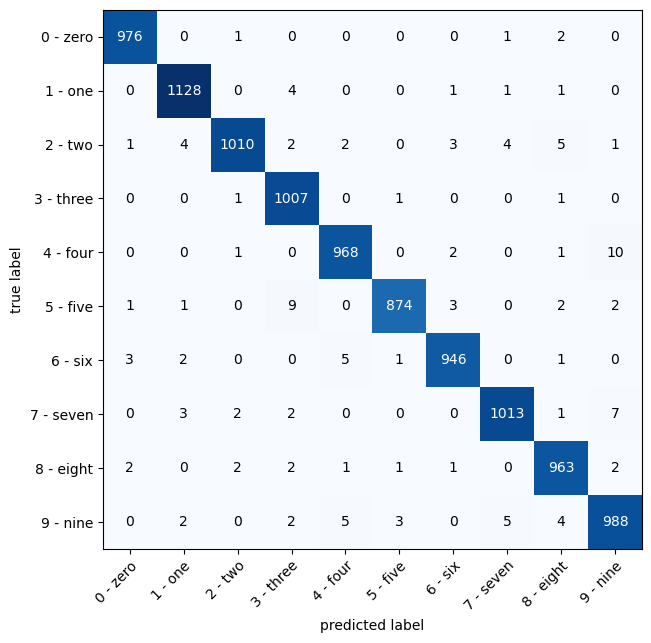

In [137]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

model_on_gpu.eval()

preds = []
with torch.inference_mode():
    for sample, y in test_data:
        sample = sample.to(device)
        y_pred = model_on_gpu(sample).cpu()
        preds.append(torch.argmax(y_pred, dim=1))

preds = torch.cat(preds, dim=0)
print(len(preds))
print(preds[:10])
print(MNIST_test.targets[:10])

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=preds,
                         target=MNIST_test.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?